In [24]:
import pandas as pd 
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
db_path = f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"



engine = create_engine(db_path)

query = """
SELECT f.*, d.gender, d.senior_citizen, d.partner, d.dependents
FROM fact_churn f
JOIN dim_customer d ON f.customer_sk = d.customer_sk
"""

df = pd.read_sql(query, engine)
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   churn_sk         7043 non-null   int64  
 1   customer_sk      7043 non-null   int64  
 2   tenure           7043 non-null   int64  
 3   monthly_charges  7043 non-null   float64
 4   total_charges    7043 non-null   float64
 5   is_churned       7043 non-null   bool   
 6   gender           7043 non-null   str    
 7   senior_citizen   7043 non-null   int64  
 8   partner          7043 non-null   str    
 9   dependents       7043 non-null   str    
dtypes: bool(1), float64(2), int64(4), str(3)
memory usage: 502.2 KB
None
   churn_sk  customer_sk  tenure  monthly_charges  total_charges  is_churned  \
0         1          469       1            29.85          29.85       False   
1         2         4801      34            56.95        1889.50       False   
2         3         1416       2      

In [25]:
print(df.describe())

print(df['is_churned'].value_counts(normalize=True))

          churn_sk  customer_sk       tenure  monthly_charges  total_charges  \
count  7043.000000  7043.000000  7043.000000      7043.000000    7043.000000   
mean   3522.000000  3522.000000    32.371149        64.761692    2279.734304   
std    2033.283305  2033.283305    24.559481        30.090047    2266.794470   
min       1.000000     1.000000     0.000000        18.250000       0.000000   
25%    1761.500000  1761.500000     9.000000        35.500000     398.550000   
50%    3522.000000  3522.000000    29.000000        70.350000    1394.550000   
75%    5282.500000  5282.500000    55.000000        89.850000    3786.600000   
max    7043.000000  7043.000000    72.000000       118.750000    8684.800000   

       senior_citizen  
count     7043.000000  
mean         0.162147  
std          0.368612  
min          0.000000  
25%          0.000000  
50%          0.000000  
75%          0.000000  
max          1.000000  
is_churned
False    0.73463
True     0.26537
Name: proportion, 

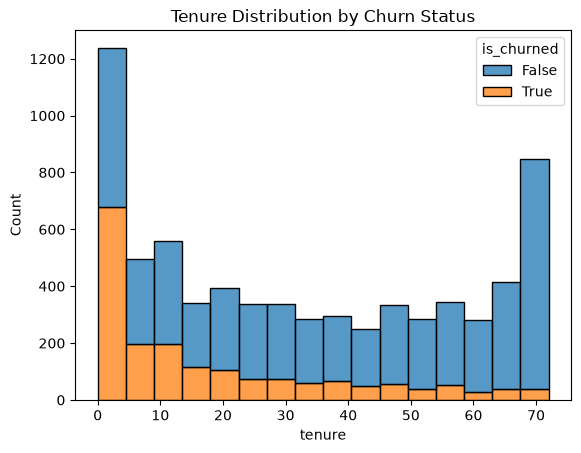

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data = df, x = 'tenure', hue = 'is_churned', multiple='stack')
plt.title('Tenure Distribution by Churn Status')
plt.show()

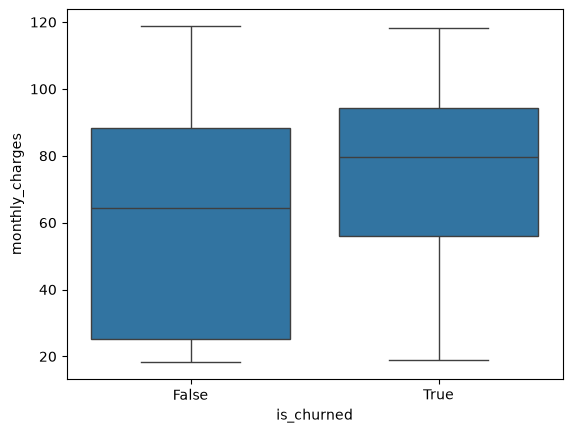

In [27]:
sns.boxplot(data = df, x = 'is_churned', y = 'monthly_charges')

plt.show()

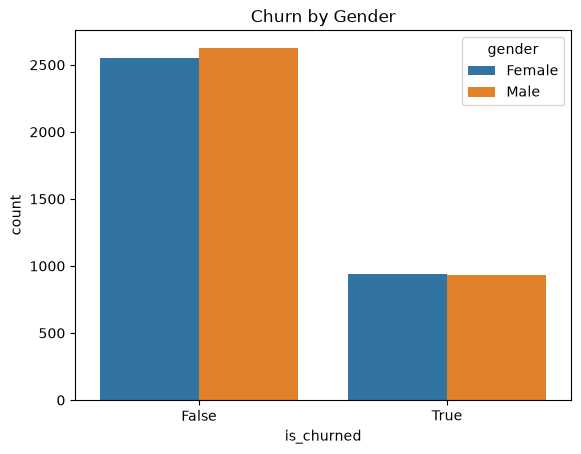

In [28]:
sns.countplot(data = df, x = 'is_churned', hue = 'gender')
plt.title('Churn by Gender')
plt.show()

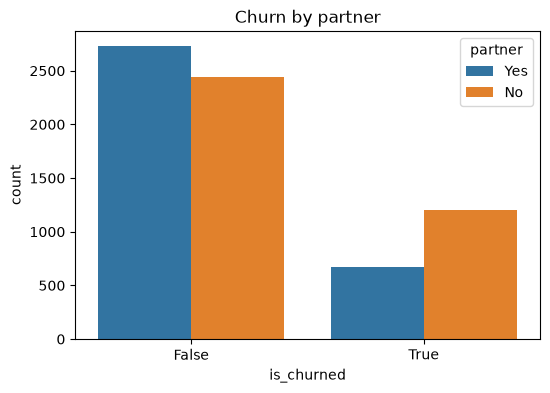

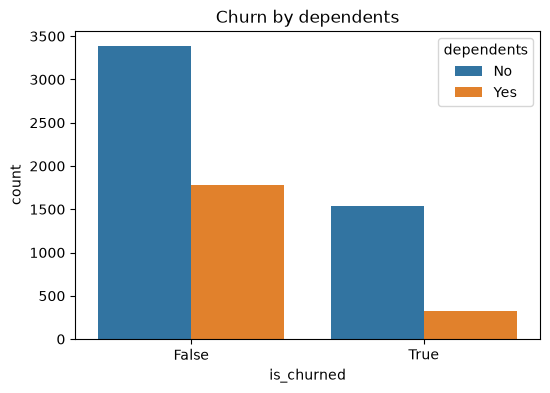

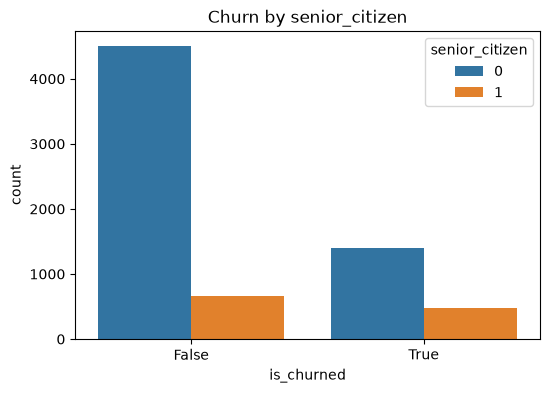

In [29]:
categorical_cols = ['partner', 'dependents', 'senior_citizen']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='is_churned', hue=col)
    plt.title(f'Churn by {col}')
    plt.show()

In [ ]:
print(pd.crosstab(df['partner'], df['is_churned'], normalize='index'))
print(pd.crosstab(df['dependents'], df['is_churned'], normalize='index'))
print(pd.crosstab(df['senior_citizen'], df['is_churned'], normalize='index'))


is_churned     False     True 
partner                       
No          0.670420  0.329580
Yes         0.803351  0.196649
is_churned     False     True 
dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502
is_churned         False     True 
senior_citizen                    
0               0.763938  0.236062
1               0.583187  0.416813


,churn_sk,customer_sk,tenure,monthly_charges,total_charges,is_churned,gender,senior_citizen,partner,dependents
0,1,469,1,29.85,29.85,False,Female,0,Yes,No
1,2,4801,34,56.95,1889.50,False,Male,0,No,No
2,3,1416,2,53.85,108.15,True,Male,0,No,No
3,4,3798,45,42.30,1840.75,False,Male,0,No,No
4,5,3611,2,70.70,151.65,True,Female,0,No,No


In [32]:
df_model = pd.get_dummies(df, columns = ['gender', 'partner', 'dependents', 'senior_citizen'], drop_first=True)

df_model.head()

,churn_sk,customer_sk,tenure,monthly_charges,total_charges,is_churned,gender_Male,partner_Yes,dependents_Yes,senior_citizen_1
0,1,469,1,29.85,29.85,False,False,True,False,False
1,2,4801,34,56.95,1889.50,False,True,False,False,False
2,3,1416,2,53.85,108.15,True,True,False,False,False
3,4,3798,45,42.30,1840.75,False,True,False,False,False
4,5,3611,2,70.70,151.65,True,False,False,False,False
